# 04 · QVDF on real data — calibrated power laws in D/C reproduce the day (I-10, 2018)

The Queue Volume-Delay Function connects the demand-to-capacity ratio
**D/C** to congestion duration **P** and the worst speed **v_t2** with
power laws, so a planning model can *reconstruct the whole speed day* from
its demand input. (Honest note: D here is accumulated flow used as a
demand proxy — true oversaturated demand is not observable at the
bottleneck detector itself; see the Glossary entry for D.) Convention that matters: **D/C is in HOURS** (accumulated
per-lane demand ÷ per-lane hourly capacity), not a plain ratio — getting
this wrong once produced 100% NaN fits (documented in
[FIXES](../docs/FIXES_CBI_PLUS_2026-07-07.md), issue F1).

Data: in-repo Caltrans PeMS, I-10 East, March 2018 — the same data behind
the [QVDF paper reproduction](../benchmarks/qvdf_paper_i10/index.html).

In [1]:
%matplotlib inline
# If cbi-plus is pip-installed this import just works; on a raw repo
# checkout we add the repo root to the path instead.
try:
    import cbi_pipeline
except ImportError:
    import sys
    from pathlib import Path
    sys.path.insert(0, str(Path.cwd().parent))
from cbi_pipeline import api
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 3.5)
plt.rcParams["figure.dpi"] = 90
print("cbi-plus", api.version())

cbi-plus 2.2.0


In [2]:
df = api.load_pems(path="../benchmarks/I-10/link_performance.json")
keep = df["sensor_uid"].unique()[:3]          # 3 sensors keeps this notebook fast
df = df[df["sensor_uid"].isin(keep)]
print(f"{df['sensor_uid'].nunique()} sensors, {df['datetime'].dt.date.nunique()} days, {len(df):,} rows")

[load_pems] using dataset-local metadata: ..\benchmarks\I-10\sensor_information.csv


3 sensors, 31 days, 26,784 rows


In [3]:
out = api.diagnose(df, n_boot=20)
eps = out["episodes"]
valid = eps[eps["is_valid_for_mu"]]
print(f"episodes: {len(eps)}   valid for calibration: {len(valid)}")
out["fd_summary"].round(2)

   [stage2] detector: packaged detector (NaN-gap guard + 2-bin persistence active)


   [stage2] boundary-merge: stitched 82 MD+PM episode pairs into MDPM (constituents kept, de-validated)


   [stage6] CBI ranking: 10 sensor-periods; top-5:
      #1  pems::716081           MDPM  score=6.8233   queued_passive
      #2  pems::717008           MDPM  score=6.1132   spillback_source
      #3  pems::716087           MDPM  score=4.9478   queued_passive
      #4  pems::717008           AM    score=0.7866   active_bottleneck
      #5  pems::716087           PM    score=0.3319   queued_passive
episodes: 361   valid for calibration: 119


,sensor_uid,capacity_vphpl,v_f_mph,r_squared,fit_ok
0,pems::716081,1423.17,75.05,0.97,True
1,pems::716087,1441.75,71.73,0.97,True
2,pems::717008,1417.17,67.56,0.95,True


In [4]:
params = out["qvdf"]["params"] if isinstance(out["qvdf"], dict) and "params" in out["qvdf"] else None
params.round(3) if params is not None else out["qvdf"]

,sensor_uid,period,n_days,vf_mph,f_d,n_exp,P_r2,alpha,beta,v_t2_r2,f_p,s_exp,v_avg_r2
0,pems::716081,AM,21,75.046,4.000,-0.000,NaN,6.540000e-01,0.423,0.078,0.804,0.070,0.078
1,pems::716081,MD,18,75.046,2.138,0.759,0.732,2.602000e+00,0.480,0.035,0.633,0.059,0.040
2,pems::716081,PM,17,75.046,3.747,0.072,0.262,9.061910e+02,-3.938,0.629,0.359,-0.364,0.579
3,pems::716087,PM,18,71.727,4.000,0.000,NaN,1.100171e+03,-4.374,0.572,0.270,-0.622,0.581
4,pems::716087,AM,19,71.727,4.000,-0.000,NaN,6.380000e-01,0.286,0.023,0.806,0.046,0.023
5,pems::716087,MD,18,71.727,5.403,0.070,0.092,7.730000e-01,0.757,0.025,0.773,0.119,0.027
6,pems::717008,AM,17,67.563,4.000,-0.000,NaN,1.588000e+00,-0.213,0.001,0.686,-0.044,0.001
7,pems::717008,MD,16,67.563,6.074,-0.010,0.002,5.558900e+01,-1.749,0.308,0.401,-0.265,0.306
8,pems::717008,PM,19,67.563,4.000,-0.000,NaN,1.045200e+01,-1.021,0.416,0.522,-0.148,0.416
9,pems::716081,MDPM,19,75.046,1.686,0.892,0.966,1.579700e+01,-0.390,0.096,0.517,-0.041,0.107


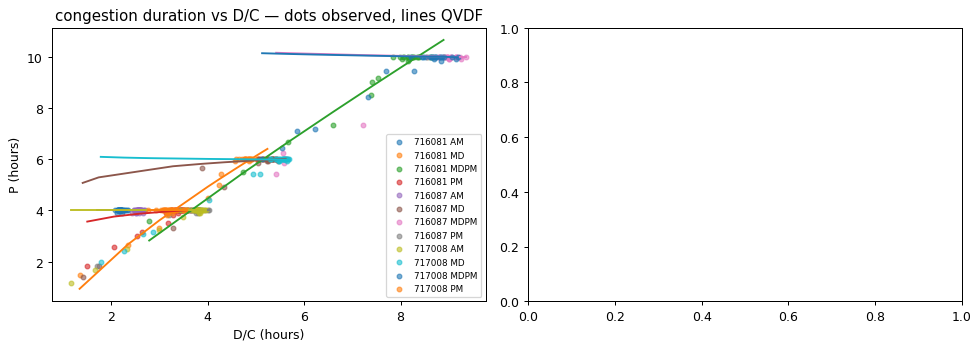

In [5]:
pred = out["qvdf"]["predictions"]
have = pred.dropna(subset=["P_pred_hours"]) if "P_pred_hours" in pred.columns else pred
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for (sid, period), g in have.groupby(["sensor_uid", "period"]):
    ax[0].scatter(g["D_over_C"], g["P_hours"], s=14, alpha=0.6, label=f"{sid[-6:]} {period}")
    gg = g.sort_values("D_over_C")
    ax[0].plot(gg["D_over_C"], gg["P_pred_hours"], lw=1.5)
ax[0].set_xlabel("D/C (hours)"); ax[0].set_ylabel("P (hours)")
ax[0].set_title("congestion duration vs D/C — dots observed, lines QVDF")
ax[0].legend(fontsize=7)
if "v_t2_pred" in have.columns:
    ax[1].scatter(have["min_speed_mph"], have["v_t2_pred"], s=14, alpha=0.6, color="#2563eb")
    lim = [0, max(have["min_speed_mph"].max(), 60)]
    ax[1].plot(lim, lim, color="#b3261e", ls="--", lw=1)
    ax[1].set_xlabel("observed v_t2 (mph)"); ax[1].set_ylabel("QVDF-predicted v_t2 (mph)")
    ax[1].set_title("worst-speed round trip")
plt.tight_layout(); plt.show()

## Why planners care

A regional model produces demand (D). With calibrated QVDF elasticities the
model gets back *when congestion starts, how long it lasts, and how slow it
gets* — not just a static V/C flag. That is the bridge from data diagnosis
(this repo) to planning models (the AMS chain in
[AMS_FRAMEWORK](../docs/AMS_FRAMEWORK.md)).

### Exercises
1. The paper's exact figures and tables regenerate with
   `python ../benchmarks/qvdf_paper_i10/reproduce_qvdf_paper.py` (~2 min).
2. Change `keep` to different sensors — how stable are the elasticities?
3. Find one `event`-regime day in `out["episodes"]` and explain why it
   should NOT calibrate the recurring model.